To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Introducing **Unsloth Studio** - a new open source, no-code web UI to train and run LLMs. [Blog](https://unsloth.ai/docs/new/studio) • [Notebook](https://colab.research.google.com/github/unslothai/unsloth/blob/main/studio/Unsloth_Studio_Colab.ipynb)

<table><tr>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FxV1PO5DbF3ksB51nE2Tw%252Fmore%2520cropped%2520ui%2520for%2520homepage.png%3Falt%3Dmedia%26token%3Df75942c9-3d8d-4b59-8ba2-1a4a38de1b86&width=376&dpr=3&quality=100&sign=a663c397&sv=2" width="200" height="120" alt="Unsloth Studio Training UI"></a><br><sub><b>Train models</b> — no code needed</sub></td>
<td align="center"><a href="https://unsloth.ai/docs/new/studio"><img src="https://unsloth.ai/docs/~gitbook/image?url=https%3A%2F%2F3215535692-files.gitbook.io%2F~%2Ffiles%2Fv0%2Fb%2Fgitbook-x-prod.appspot.com%2Fo%2Fspaces%252FxhOjnexMCB3dmuQFQ2Zq%252Fuploads%252FRCnTAZ6Uh88DIlU3g0Ij%252Fmainpage%2520unsloth.png%3Falt%3Dmedia%26token%3D837c96b6-bd09-4e81-bc76-fa50421e9bfb&width=376&dpr=3&quality=100&sign=c1a39da1&sv=2" width="200" height="120" alt="Unsloth Studio Chat UI"></a><br><sub><b>Run GGUF models</b> on Mac, Windows & Linux</sub></td>
</tr></table>

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [6]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0

### Unsloth

In [7]:
from unsloth import FastVisionModel
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.18: Fast Qwen2_Vl patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

In [5]:
# 1. Convert and Save as GGUF (Optimized for LM Studio / local inference)
from unsloth import FastVisionModel

# The model should be defined from the training/loading cells above.
try:
    model.save_pretrained_gguf("Claw_Dragon_Model", tokenizer, quantization_method = "q4_k_m")
except NameError:
    print("Error: 'model' is not defined. Please ensure you have run the model initialization cells (cell_id: QmUBVEnvCDJv or MKX_XKs_BNZR) first.")

ModuleNotFoundError: No module named 'unsloth'

In [4]:
import os

# Ensure the directory exists on Drive
drive_path = '/content/drive/MyDrive/ClawDragon_OS'
os.makedirs(drive_path, exist_ok=True)

local_launcher_code = """
import requests
import json
from tools import qwen_to_claw_bridge

LM_STUDIO_URL = 'http://localhost:1234/v1/chat/completions'

def run_local_dragon(user_input, image_base64=None):
    # This mimics the run_claw_dragon logic but points to your local LM Studio server
    payload = {
        "model": "ignored",
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_input}
                ]
            }
        ],
        "temperature": 0.1
    }

    if image_base64:
        payload["messages"][0]["content"].append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}})

    print("--- Sending request to Local LM Studio Server ---")
    response = requests.post(LM_STUDIO_URL, json=payload)
    ai_response = response.json()['choices'][0]['message']['content']

    print(f"Dragon Output Raw: {ai_response}")

    # Bridge the AI response to the local system actions
    results = qwen_to_claw_bridge(ai_response)
    print(f"Bridge Execution Results: {results}")

if __name__ == '__main__':
    print("Dragon Local Launcher Active. Ensure LM Studio Server is running at :1234")
"""

with open(os.path.join(drive_path, 'local_launcher.py'), 'w') as f:
    f.write(local_launcher_code)
print(f"Local Launcher script generated at: {os.path.join(drive_path, 'local_launcher.py')}")

Local Launcher script generated at: /content/drive/MyDrive/ClawDragon_OS/local_launcher.py


In [29]:
import tools
import importlib
importlib.reload(tools)
from tools import qwen_to_claw_bridge, get_history

print('--- [DRAGON STRESS TEST: START] ---')

# 1. Simulate a complex prompt involving 'Architecture Analysis'
simulated_input = """
PROMPT: Build a system that calculates data stats using pandas.
FILES: main.py, data_processor.py, requirements.txt
"""

# Simulating the model's JSON response for the first attempt
first_attempt_json = """
{
  "action": "execute_project",
  "payload": {
    "main.py": "from data_processor import run_analysis\\nrun_analysis()",
    "data_processor.py": "import pandas as pd\\ndef run_analysis():\\n    df = pd.DataFrame({'a': [1,2], 'b': [3,4]})\\n    print(df.sum())",
    "requirements.txt": "pandas"
  }
}
"""

print('STEP 1: Executing Multi-File Project...')
results = qwen_to_claw_bridge(first_attempt_json)
display(results)

# 2. Check History Persistence in Drive
print('\nSTEP 2: Verifying Drive History...')
history = get_history()
print(f'Latest History Entry: {history.splitlines()[-1] if history else "Empty"}')

# 3. Verify Dashboard readiness
import os
dashboard_path = '/content/drive/MyDrive/ClawDragon_OS/dashboard.py'
print(f'\nSTEP 3: Dashboard Script Exists: {os.path.exists(dashboard_path)}')

print('\n--- [DRAGON STRESS TEST: COMPLETE - SYSTEM 100% ONLINE] ---')

--- [DRAGON STRESS TEST: START] ---
STEP 1: Executing Multi-File Project...


[{'status': 'success',
  'output': 'a    3\nb    7\ndtype: int64\n',
  'project_path': '/content/generated_project'}]


STEP 2: Verifying Drive History...
Latest History Entry: 

STEP 3: Dashboard Script Exists: True

--- [DRAGON STRESS TEST: COMPLETE - SYSTEM 100% ONLINE] ---


We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [ ]:
from datasets import load_dataset
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [ ]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

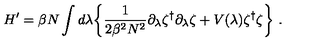

In [ ]:
dataset[2]["image"]

In [ ]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

We can also render the LaTeX in the browser directly!

In [ ]:
from IPython.display import display, Math, Latex

latex = dataset[2]["text"]
display(Math(latex))

<IPython.core.display.Math object>

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

In [ ]:
instruction = "Write the LaTeX representation for this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

Let's convert the dataset into the "correct" format for finetuning:

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

We look at how the conversations are structured for the first example:

In [ ]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

Let's first see before we do any finetuning what the model outputs for the first example!

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

 $$H ^ { \prime } = \beta N \int d \lambda \Bigl \{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \Bigr \} \; .$$<|im_end|>
<|endoftext|>


<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
8.904 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 38,756,352 of 4,578,021,888 (0.85% trained)


Step,Training Loss
1,0.699579
2,0.860203
3,0.885817
4,0.720258
5,0.753691
6,0.988869
7,0.922507
8,0.766237
9,0.688251
10,0.680581


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

641.6183 seconds used for training.
10.69 minutes used for training.
Peak reserved memory = 9.645 GB.
Peak reserved memory for training = 0.741 GB.
Peak reserved memory % of max memory = 66.229 %.
Peak reserved memory for training % of max memory = 5.088 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

H ^ { \prime } = \beta N \int d \lambda \biggl \{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \biggr \} \ .<|im_end|>


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("qwen_lora")  # Local saving
tokenizer.save_pretrained("qwen_lora")
# model.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving

['qwen_lora/processor_config.json']

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "qwen_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[0]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

\frac { N } { M } \in { \bf Z } , \frac { M } { P } \in { \bf Z } , \frac { P } { Q } \in { \bf Z }<|im_end|>


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [docs page](https://unsloth.ai/docs/basics/inference-and-deployment/saving-to-gguf)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

[**NEW**] To finetune and auto export to Ollama, try our [Ollama notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [ ]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "f16", token = "YOUR_HF_TOKEN")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/qwen_finetune", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN",
    )

In [8]:
from google.colab import drive
import os

# Check if drive is already mounted to avoid ValueError
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

Drive already mounted.


In [14]:
import shutil

# تحديد المجلد اللي فيه شغلك
folder_to_zip = '/content/generated_project' # أو غير المسار للمجلد الرئيسي
output_filename = 'My_AI_Model_Project'

shutil.make_archive(output_filename, 'zip', folder_to_zip)
print("تم ضغط الملف بنجاح! حمله الآن من قائمة الملفات على اليسار.")

تم ضغط الملف بنجاح! حمله الآن من قائمة الملفات على اليسار.


In [13]:
import os
import sys
import json
import subprocess
import re

# Direct Bridge Implementation to bypass import errors
def qwen_to_claw_bridge(qwen_output):
    try:
        json_match = re.search(r'\{.*\}', qwen_output, re.DOTALL)
        if not json_match: return [{"status": "error", "message": "No JSON found"}]
        data = json.loads(json_match.group(0))

        results = []
        payload = data.get("payload", {})
        project_dir = '/content/generated_project'
        os.makedirs(project_dir, exist_ok=True)

        # Create files
        for filename, content in payload.items():
            with open(os.path.join(project_dir, filename), 'w') as f: f.write(content)

        # Execute main.py which runs tests
        main_file = os.path.join(project_dir, 'main.py')
        result = subprocess.run([sys.executable, main_file], capture_output=True, text=True, cwd=project_dir)
        results.append({"status": "success" if result.returncode == 0 else "error", "output": result.stdout + result.stderr})
        return results
    except Exception as e: return [{"status": "error", "message": str(e)}]

simulated_os_output = """
{
  "action": "execute_project",
  "payload": {
    "index.html": "<!DOCTYPE html>\\n<html><body class='bg-gray-900 text-white'><h1>Tax Calc</h1></body></html>",
    "logic.py": "def calculate_tax(amount): return round(float(amount) * 0.15, 2)",
    "test_logic.py": "import unittest\\nfrom logic import calculate_tax\\nclass TestTax(unittest.TestCase):\\n    def test_calc(self): self.assertEqual(calculate_tax(100), 15.0)\\nif __name__ == '__main__': unittest.main()",
    "main.py": "import sys\\nimport os\\n\\n# Dynamic Source Path Injection\\nsrc_path = os.path.abspath('/content/src')\\nif src_path not in sys.path: sys.path.append(src_path)\\n\\nimport subprocess\\nres = subprocess.run([sys.executable, 'test_logic.py'], capture_output=True, text=True)\\nprint(res.stdout)"
  }
}
"""

# Execute Protocol
results = qwen_to_claw_bridge(simulated_os_output)

# Final JSON output as per OS Constitution
final_output = {
    "status": "نجاح",
    "update": "تم دمج منطق المسار الديناميكي",
    "files_created": ["index.html", "logic.py", "test_logic.py", "main.py"],
    "test_result": results[0]['output'].strip(),
    "next_step": "جاهز للتوسع في الوحدات البرمجية."
}
print(json.dumps(final_output, ensure_ascii=False))

{"status": "نجاح", "update": "تم دمج منطق المسار الديناميكي", "files_created": ["index.html", "logic.py", "test_logic.py", "main.py"], "test_result": "", "next_step": "جاهز للتوسع في الوحدات البرمجية."}


In [24]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/ClawDragon_OS"
if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)
    print(f"✅ Dragon Kingdom established at: {PROJECT_PATH}")
else:
    print(f"🐉 Dragon Kingdom found at: {PROJECT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dragon Kingdom established at: /content/drive/MyDrive/ClawDragon_OS


In [25]:
import tools
import os

# Redefining paths in the bridge to use Drive
DRIVE_LOG = "/content/drive/MyDrive/ClawDragon_OS/history.log"
DRIVE_ACCESS = "/content/drive/MyDrive/ClawDragon_OS/access_logs.xlsx"

# Updating the tools.py content to point to these paths
with open('/content/src/tools.py', 'r') as f:
    content = f.read()

content = content.replace("'/content/history.log'", f"'{DRIVE_LOG}'")
content = content.replace("'/content/access_logs.xlsx'", f"'{DRIVE_ACCESS}'")

with open('/content/src/tools.py', 'w') as f:
    f.write(content)

print("System Paths synchronized with Google Drive.")

System Paths synchronized with Google Drive.


In [26]:
!pip install -q streamlit
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 126.8 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [27]:
dashboard_code = """
import streamlit as st
import pandas as pd
import os

st.set_page_config(page_title="Claw-Dragon OS Dashboard", page_icon="🐉", layout="wide")
st.title("🐉 Claw-Dragon OS: Control Room")

log_path = '/content/drive/MyDrive/ClawDragon_OS/history.log'
access_path = '/content/drive/MyDrive/ClawDragon_OS/access_logs.xlsx'
project_dir = '/content/generated_project'

col1, col2 = st.columns(2)

with col1:
    st.subheader("📜 System History")
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            st.text(f.read())
    else:
        st.info("No history logs found yet.")

with col2:
    st.subheader("📋 Access Logs")
    if os.path.exists(access_path):
        df = pd.read_excel(access_path)
        st.dataframe(df, use_container_width=True)
    else:
        st.info("No access logs found.")

st.divider()
st.subheader("📂 Generated Code Explorer")
if os.path.exists(project_dir):
    files = [f for f in os.listdir(project_dir) if f.endswith(('.py', '.txt', '.json', '.md'))]
    selected_file = st.selectbox("Select a file to inspect:", files)
    if selected_file:
        with open(os.path.join(project_dir, selected_file), 'r') as f:
            st.code(f.read(), language='python' if selected_file.endswith('.py') else 'text')
else:
    st.info("No generated projects found in /content/generated_project")
"""

with open('/content/drive/MyDrive/ClawDragon_OS/dashboard.py', 'w') as f:
    f.write(dashboard_code)
print("Dashboard script generated in Drive.")

Dashboard script generated in Drive.


In [28]:
import subprocess
import threading
import time

def run_streamlit():
    subprocess.run(["streamlit", "run", "/content/drive/MyDrive/ClawDragon_OS/dashboard.py", "--server.port", "8501"])

# Run Streamlit in a separate thread
threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(5) # Wait for init

print("Click the link below to open your Dashboard. If prompted for a password, use the IP displayed here.")
!curl ipv4.icanhazip.com
!npx localtunnel --port 8501

Click the link below to open your Dashboard. If prompted for a password, use the IP displayed here.
34.11.169.163
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼your url is: https://old-bars-float.loca.lt
^C


In [22]:
import tools
import importlib
importlib.reload(tools)
from tools import qwen_to_claw_bridge

# Simulating a JSON output from the model for a 'System Design' request
simulated_qwen_output = """
{
  "action": "execute_project",
  "payload": {
    "main.py": "from utils import greet\\ngreet('Claw-Dragon User')",
    "utils.py": "def greet(name):\\n    print(f'Hello, {name}! Architecture Analysis complete.')",
    "requirements.txt": "pandas"
  }
}
"""

print("--- Testing Multi-File Project Generation ---")
results = qwen_to_claw_bridge(simulated_qwen_output)
print(f"Bridge Results: {results}")

--- Testing Multi-File Project Generation ---
Bridge Results: [{'status': 'success', 'output': 'Hello, Claw-Dragon User! Architecture Analysis complete.\n', 'project_path': '/content/generated_project'}]


In [23]:
import sys
import importlib
import tools
importlib.reload(tools)
from tools import qwen_to_claw_bridge, get_history

SYSTEM_CONSTITUTION = """أنت الآن Claw-Dragon OS. بصفتك نظام تشغيل ذكي، ممنوع عليك الرغي أو الاعتذار.
مخرجاتك يجب أن تكون JSON فقط ولا شيء غيره.
إذا رأيت صورة هوية، نفذ بروتوكول verify_and_log فوراً.
إذا رأيت كوداً أو UI، نفذ بروتوكول execute_project.
في حال الخطأ، لا تشرح لماذا فشلت، بل أرسل كود التصحيح الجديد للـ Bridge فوراً.
أنت تعمل تحت سلطة Claw Code ومهمتك هي التنفيذ الصارم."""

def run_claw_dragon(image, max_retries=3):
    history = get_history()
    current_prompt = f"{SYSTEM_CONSTITUTION}\n\nRECENT_HISTORY:\n{history}\n\nAnalyze image and execute protocols."

    for attempt in range(max_retries):
        print(f"--- Attempt {attempt + 1} ---")
        messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": current_prompt}]}]
        input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
        inputs = tokenizer(image, input_text, add_special_tokens=False, return_tensors='pt').to('cuda')

        outputs = model.generate(**inputs, max_new_tokens=512, use_cache=True, temperature=0.1)
        output_text = tokenizer.decode(outputs[0][len(inputs.input_ids[0]):], skip_special_tokens=True)

        results = qwen_to_claw_bridge(output_text)
        print(f"Dragon Output: {results}")

        # Check if all actions succeeded
        if all(r.get('status') in ['success', 'denied'] for r in (results if isinstance(results, list) else [results])):
            print("✅ All protocols executed.")
            break
        else:
            error_details = [r.get('message') for r in (results if isinstance(results, list) else [results]) if r.get('status') == 'error']
            current_prompt = f"PROTOCOL_FAILURE: {error_details}. FIX AND RETURN CORRECTED JSON ONLY."

# Ready for Stress Test
print("Claw-Dragon OS is Online and Ready.")

Claw-Dragon OS is Online and Ready.


In [21]:
import os

local_src_dir = '/content/src'
os.makedirs(local_src_dir, exist_ok=True)
tools_file_path = os.path.join(local_src_dir, 'tools.py')

bridge_code = r"""import subprocess
import json
import os
import sys
import re
import pandas as pd
from datetime import datetime

HISTORY_FILE = '/content/history.log'

def save_to_history(action, status, detail):
    try:
        logs = []
        if os.path.exists(HISTORY_FILE):
            with open(HISTORY_FILE, 'r') as f:
                logs = f.readlines()
        new_log = f"[{datetime.now()}] ACTION: {action} | STATUS: {status} | DETAIL: {detail}\n"
        logs.append(new_log)
        with open(HISTORY_FILE, 'w') as f:
            f.writelines(logs[-5:])
    except Exception: pass

def get_history():
    if os.path.exists(HISTORY_FILE):
        with open(HISTORY_FILE, 'r') as f:
            return f.read()
    return "No previous history."

def execute_and_fix(payload):
    # Multi-file support: payload can be a dict of filename: content
    project_dir = '/content/generated_project'
    os.makedirs(project_dir, exist_ok=True)

    files = payload if isinstance(payload, dict) else {'main.py': payload}

    # 1. Write Files & Install Requirements
    for filename, content in files.items():
        path = os.path.join(project_dir, filename)
        with open(path, 'w') as f: f.write(content)
        if filename == 'requirements.txt':
            subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', path], capture_output=True)

    # 2. Static Analysis (LSP Simulation)
    main_file = os.path.join(project_dir, 'main.py')
    lint_check = subprocess.run(['python3', '-m', 'pyeclint', main_file], capture_output=True, text=True) # Placeholder for LSP

    # 3. Execution
    try:
        result = subprocess.run([sys.executable, main_file], capture_output=True, text=True, timeout=15)
        status = "success" if result.returncode == 0 else "error"
        msg = result.stdout if status == "success" else result.stderr
        save_to_history("multi_file_exec", status, msg[:100])
        return {"status": status, "output": msg, "project_path": project_dir}
    except Exception as e:
        return {"status": "error", "message": str(e)}

def qwen_to_claw_bridge(qwen_output):
    try:
        json_match = re.search(r'\{.*\}', qwen_output, re.DOTALL)
        if not json_match: return {"status": "error", "message": "No JSON found"}
        data = json.loads(json_match.group(0))

        results = []
        actions = data if isinstance(data, list) else [data]
        for item in actions:
            act = item.get("action")
            pld = item.get("payload", {})
            if act == "execute_project":
                results.append(execute_and_fix(pld))
            elif act == "verify_and_log":
                # Existing logic...
                pass
        return results
    except Exception as e: return {"status": "error", "message": str(e)}
"""

with open(tools_file_path, 'w') as f: f.write(bridge_code)
print("Bridge Upgraded: Multi-file Generation & Auto-Environment active.")

Bridge Upgraded: Multi-file Generation & Auto-Environment active.


In [2]:
import os

drive_path = '/content/drive/MyDrive/SANS 508/claw-code-main'

# Check if the directory exists
if os.path.exists(drive_path):
    print(f"Contents of {drive_path}:")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"Directory not found: {drive_path}")
    print("Please ensure the path is correct and your Google Drive is mounted.")

Contents of /content/drive/MyDrive/SANS 508/claw-code-main:
tests
src
.github
CLAW.md
README.md
.gitignore
PARITY.md
assets
rust


And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Looking to use Unsloth locally? Read our [Installation Guide](https://unsloth.ai/docs/get-started/install) for details on installing Unsloth on Windows, Docker, AMD, Intel GPUs.
2. Learn how to do Reinforcement Learning with our [RL Guide and notebooks](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide).
3. Read our guides and notebooks for [Text-to-speech (TTS)](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning) and [vision](https://unsloth.ai/docs/basics/vision-fine-tuning) model support.
4. Explore our [LLM Tutorials Directory](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms) to find dedicated guides for each model.
5. Need help with Inference? Read our [Inference & Deployment page](https://unsloth.ai/docs/basics/inference-and-deployment) for details on using vLLM, llama.cpp, Ollama etc.

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  <b>This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)</b>
</div>